--- Sequential Search for Known Calendar Events ---
Total initial events to explain: 17


>> Testing for 'IMM'...
   Event 'IMM': KEPT. Best offset is -1 day(s) (Score: 0.3181).

>> Testing for 'Quarter-End'...
   Event 'Quarter-End': DROPPED. Best score (0.0341) too low.

>> Testing for 'Month-End'...
   Event 'Month-End': DROPPED. Best score (0.0520) too low.

--- Final Poisson Intensity Results (MLE) ---
  Period Type: Background           | Intensity (λ): 0.0127 +/- 0.0042
  Period Type: IMM Period           | Intensity (λ): 0.3333 +/- 0.1179

--- Forward Prediction Table ---
 start_date    end_date Period Type Expected Events
01 Jan 2025 16 Mar 2025  Background   0.95 +/- 0.32
17 Mar 2025 19 Mar 2025  IMM Period   1.00 +/- 0.35
20 Mar 2025 15 Jun 2025  Background   1.12 +/- 0.37
16 Jun 2025 18 Jun 2025  IMM Period   1.00 +/- 0.35
19 Jun 2025 29 Jun 2025  Background   0.14 +/- 0.05


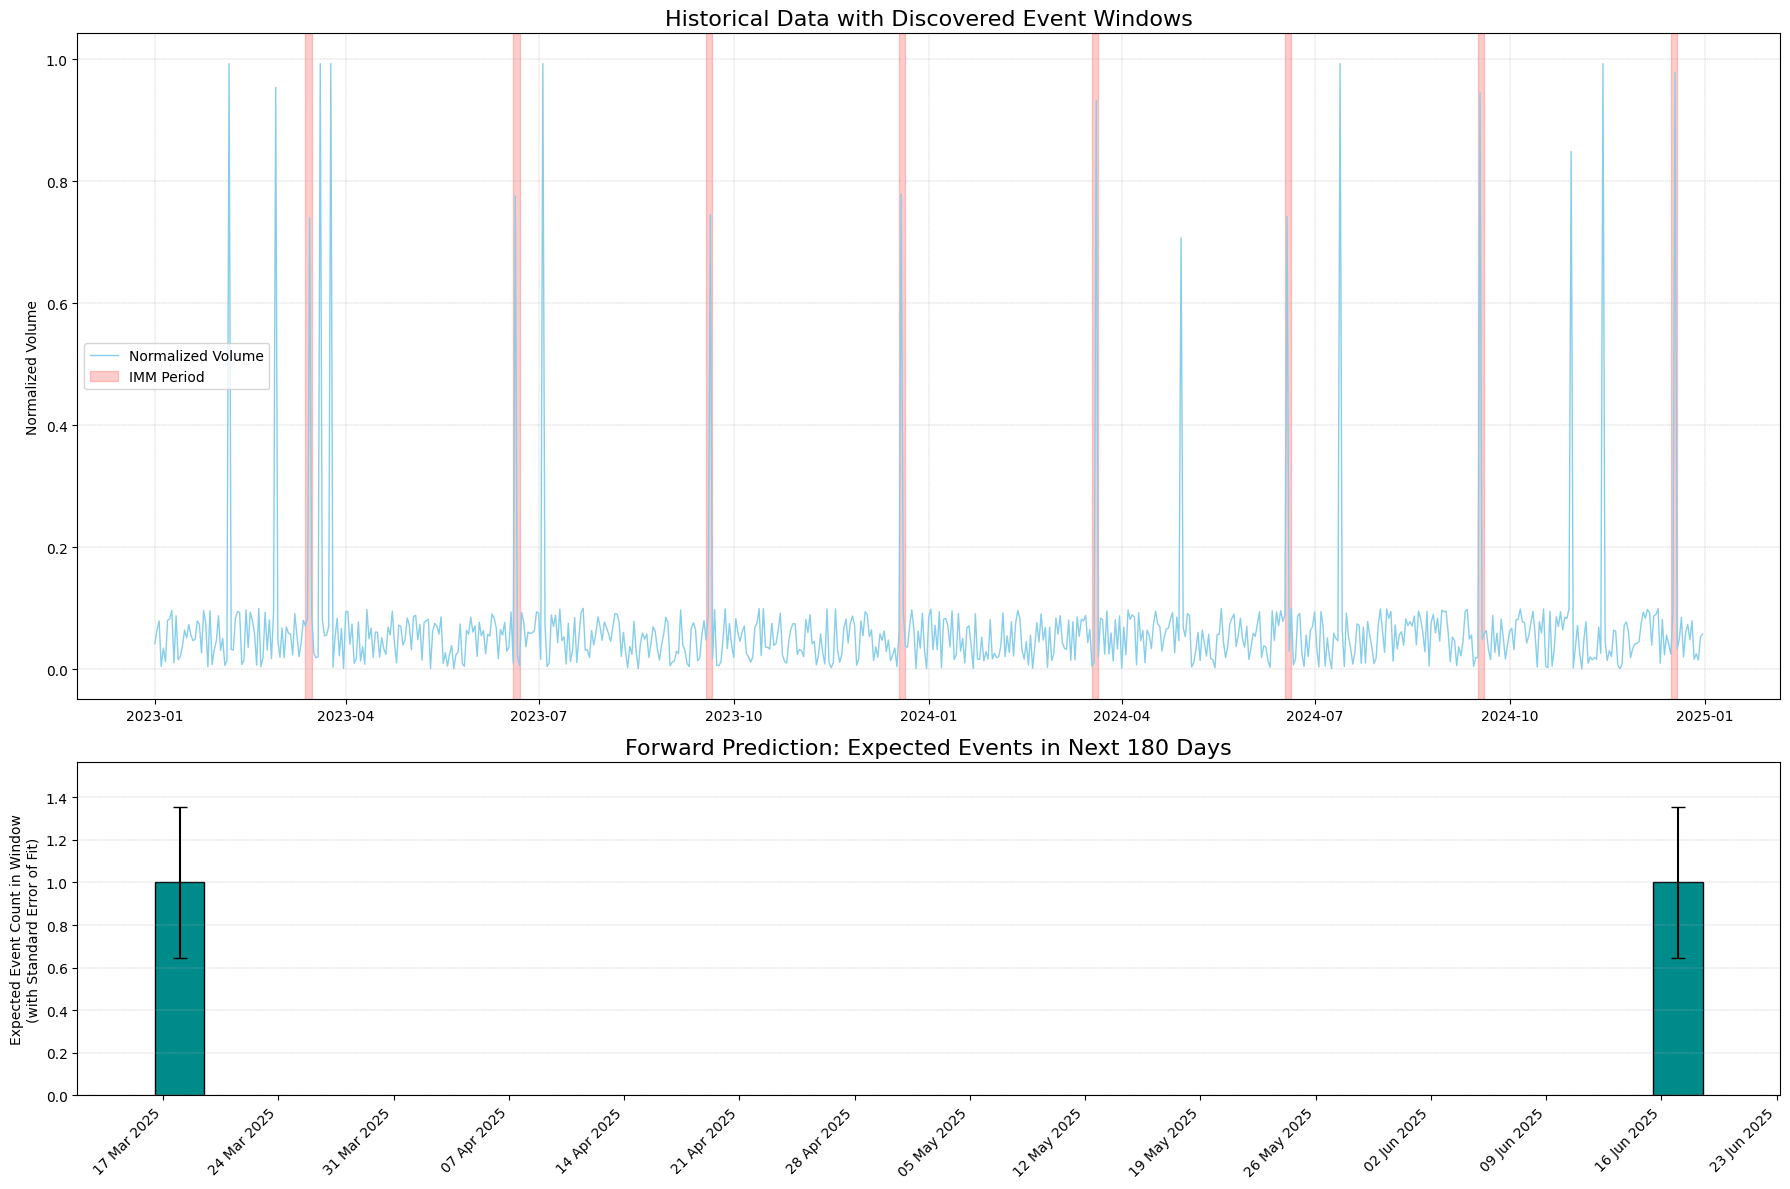

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import periodogram
from datetime import datetime, timedelta

# --- Configuration for the Prediction Model ---

EVENT_THRESHOLD = 0.65
NUM_CYCLES_TO_FIND = 1 # Max number of *unknown* cycles to find after known events
MIN_PERIOD_DAYS = 15
MAX_PERIOD_DAYS = 120
CYCLE_WINDOW_DAYS = 2 # Window size for unknown cycles
KNOWN_EVENT_WINDOW_DAYS = 1 # Window size for known events (typically tighter)
NON_CAPTURED_EVENT_PENALTY = 1.2
MINIMUM_CONCENTRATION_SCORE = 0.1
PREDICTION_DAYS_AHEAD = 180
KNOWN_EVENT_OFFSET_WINDOW = list(range(-8, 3))

# --- Helper functions ---
def is_imm_date(date):
    return (date.weekday() == 2 and date.month in [3, 6, 9, 12] and 15 <= date.day <= 21)

def get_calendar_aware_offset(period_days):
    if 28 <= period_days <= 33:
        return pd.DateOffset(months=1), 'Monthly'
    elif 88 <= period_days <= 94:
        return pd.DateOffset(months=3), 'Quarterly'
    else:
        return pd.DateOffset(days=round(period_days)), f'{round(period_days)}d'

# --- Simulation Code ---
def run_simulation(start_date, end_date):
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    df = pd.DataFrame(index=dates)
    df['volume'] = np.random.uniform(0.0, 0.1, size=len(dates))

    p_imm, p_qe, p_me, p_noise = 0.8, 0.0, 0.25, 0.01
    vol_range = [0.7, 1.0]

    imm_dates = [d for d in dates if is_imm_date(d)]

    b_dates = pd.bdate_range(start=start_date, end=end_date)
    quarter_end_dates = b_dates[b_dates.is_quarter_end].tolist()
    all_month_ends = b_dates[b_dates.is_month_end]
    month_end_dates = all_month_ends.difference(pd.to_datetime(quarter_end_dates)).tolist()

    event_calendar = {}
    # Set event precedence correctly (IMM > Quarter-End > Month-End)
    for date in imm_dates:
        event_calendar[date + timedelta(days=np.random.randint(-1, 1))] = 'IMM'
    for date in quarter_end_dates:
        shifted_date = date + timedelta(days=np.random.randint(-1, 1))
        if shifted_date not in event_calendar:
             event_calendar[shifted_date] = 'Quarter-End'
    for date in month_end_dates:
        shifted_date = date + timedelta(days=np.random.randint(-1, 1))
        if shifted_date not in event_calendar:
             event_calendar[shifted_date] = 'Month-End'

    for date, event_type in event_calendar.items():
        if date in df.index:
            if event_type == 'IMM': prob = p_imm
            elif event_type == 'Quarter-End': prob = p_qe
            else: prob = p_me

            if np.random.rand() < prob:
                df.loc[date, 'volume'] = np.random.uniform(*vol_range)

    noise_dates = df.index.difference(list(event_calendar.keys()))
    noise_events = np.random.choice(noise_dates, size=int(len(noise_dates) * p_noise), replace=False)
    df.loc[noise_events, 'volume'] = np.random.uniform(*vol_range)

    return df

# --- HYBRID MODELING ALGORITHM ---
def analyze_and_predict(time_series_df):
    df = time_series_df.copy()
    df['is_event'] = (df['volume'] >= EVENT_THRESHOLD).astype(int)
    df['period_type'] = 'Background'
    residual_events = df['is_event'].copy()

    validated_models = []

    # --- 1. Sequential Search with Fixed Precedence ---
    all_bdays = pd.bdate_range(start=df.index.min(), end=df.index.max())
    quarter_ends = all_bdays[all_bdays.is_quarter_end].tolist()
    all_month_ends = all_bdays[all_bdays.is_month_end]
    month_ends = all_month_ends.difference(pd.to_datetime(quarter_ends)).tolist()

    known_event_defs = [
        ('IMM', [d for d in df.index if is_imm_date(d)]),
        ('Quarter-End', quarter_ends),
        ('Month-End', month_ends)
    ]

    print("--- Sequential Search for Known Calendar Events ---")
    print(f"Total initial events to explain: {residual_events.sum()}\n")

    for event_name, base_dates in known_event_defs:
        print(f"\n>> Testing for '{event_name}'...")
        best_offset, best_score = None, -np.inf

        if not base_dates:
            print("   No base dates for this event type. Skipping.")
            continue

        for offset in KNOWN_EVENT_OFFSET_WINDOW:
            is_in_window = pd.Series(False, index=df.index)
            for date in base_dates:
                is_in_window.loc[date + timedelta(days=offset - KNOWN_EVENT_WINDOW_DAYS):date + timedelta(days=offset + KNOWN_EVENT_WINDOW_DAYS)] = True

            days_in_window, events_in_window = is_in_window.sum(), residual_events[is_in_window].sum()
            if days_in_window == 0 or (len(df) - days_in_window == 0): continue

            intensity_in = events_in_window / days_in_window
            intensity_out = (residual_events.sum() - events_in_window) / (len(df) - days_in_window)
            score = intensity_in - NON_CAPTURED_EVENT_PENALTY * intensity_out

            if score > best_score:
                best_score, best_offset = score, offset

        if best_score >= MINIMUM_CONCENTRATION_SCORE:
            print(f"   Event '{event_name}': KEPT. Best offset is {best_offset} day(s) (Score: {best_score:.4f}).")
            model = {'type': 'known', 'name': event_name, 'offset': best_offset, 'base_dates': base_dates}
            validated_models.append(model)

            is_in_best_window = pd.Series(False, index=df.index)
            for date in base_dates:
                offset_date = date + timedelta(days=best_offset)
                start_win, end_win = offset_date - timedelta(days=KNOWN_EVENT_WINDOW_DAYS), offset_date + timedelta(days=KNOWN_EVENT_WINDOW_DAYS)
                df.loc[(df.index >= start_win) & (df.index <= end_win) & (df['period_type'] == 'Background'), 'period_type'] = f"{event_name} Period"
                is_in_best_window.loc[start_win:end_win] = True

            residual_events[is_in_best_window] = 0
        else:
            print(f"   Event '{event_name}': DROPPED. Best score ({best_score:.4f}) too low.")

    # --- 3. Calculate Final Intensities ---
    intensity_results = {}
    print("\n--- Final Poisson Intensity Results (MLE) ---")
    grouped = df.groupby('period_type')
    for name, group in grouped:
        n_events, T_days = group['is_event'].sum(), len(group)
        intensity = n_events / T_days if T_days > 0 else 0
        std_error = np.sqrt(intensity / T_days) if T_days > 0 else 0
        intensity_results[name] = {'intensity': intensity, 'std_error': std_error}
        print(f"  Period Type: {name:<20} | Intensity (λ): {intensity:.4f} +/- {std_error:.4f}")

    # --- 4. Forward Prediction ---
    last_date = df.index[-1]
    prediction_df = pd.DataFrame(index=pd.date_range(start=last_date + timedelta(days=1), periods=PREDICTION_DAYS_AHEAD))
    prediction_df['period_type'] = 'Background'

    for model in validated_models:
        if model['type'] == 'known':
            future_base_dates = []
            if model['name'] == 'IMM':
                future_base_dates = [d for d in prediction_df.index if is_imm_date(d)]
            elif model['name'] == 'Quarter-End':
                future_bdays = pd.bdate_range(start=prediction_df.index.min(), end=prediction_df.index.max())
                future_base_dates = future_bdays[future_bdays.is_quarter_end].tolist()
            elif model['name'] == 'Month-End':
                future_bdays = pd.bdate_range(start=prediction_df.index.min(), end=prediction_df.index.max())
                qes = future_bdays[future_bdays.is_quarter_end]
                future_base_dates = future_bdays[future_bdays.is_month_end].difference(qes).tolist()

            final_dates = [d + timedelta(days=model['offset']) for d in future_base_dates]
            for date in final_dates:
                start_win, end_win = date - timedelta(days=KNOWN_EVENT_WINDOW_DAYS), date + timedelta(days=KNOWN_EVENT_WINDOW_DAYS)
                prediction_df.loc[(prediction_df.index >= start_win) & (prediction_df.index <= end_win) & (prediction_df['period_type'] == 'Background'), 'period_type'] = f"{model['name']} Period"

    # --- 5. Calculate Prediction Stats for Table ---
    window_stats = []
    block_ids = prediction_df['period_type'].ne(prediction_df['period_type'].shift()).cumsum()
    for _, window_df in prediction_df.groupby(block_ids):
        period_type = window_df['period_type'].iloc[0]
        if period_type not in intensity_results: continue
        intensity = intensity_results[period_type]['intensity']
        std_error_of_intensity = intensity_results[period_type]['std_error']

        window_length = len(window_df)
        expected_events = window_length * intensity
        error_of_prediction = window_length * std_error_of_intensity

        window_stats.append({
            'start_date': window_df.index[0], 'end_date': window_df.index[-1],
            'period_type': period_type, 'expected_events': expected_events, 'error': error_of_prediction
        })

    return df, intensity_results, validated_models, window_stats


def print_prediction_table(window_stats):
    print("\n--- Forward Prediction Table ---")
    if not window_stats:
        print("No event windows predicted.")
        return
    table_df = pd.DataFrame(window_stats)
    table_df['start_date'] = table_df['start_date'].dt.strftime('%d %b %Y')
    table_df['end_date'] = table_df['end_date'].dt.strftime('%d %b %Y')
    table_df['Expected Events'] = table_df.apply(lambda r: f"{r['expected_events']:.2f} +/- {r['error']:.2f}", axis=1)
    table_df.rename(columns={'period_type': 'Period Type'}, inplace=True)
    print(table_df[['start_date', 'end_date', 'Period Type', 'Expected Events']].to_string(index=False))

def plot_prediction_results(historical_df, window_stats, validated_models):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharex=False, gridspec_kw={'height_ratios': [2, 1]})

    ax1.plot(historical_df.index, historical_df['volume'], color='skyblue', linewidth=1, label='Normalized Volume')
    colors = {
        'IMM Period': (1.0, 0.0, 0.0, 0.2),
        'Quarter-End Period': (1.0, 0.5, 0.0, 0.25),
        'Month-End Period': (0.0, 0.5, 0.0, 0.2)
    }

    # --- CORRECTED PLOTTING LOGIC ---
    plotted_labels = set()
    # Iterate through the actual period types found in the data, in a defined order
    model_order = ['IMM Period', 'Quarter-End Period', 'Month-End Period']
    unique_periods = [p for p in model_order if p in historical_df['period_type'].unique()]

    for period_type in unique_periods:
        color = colors.get(period_type, (0.0, 0.0, 1.0, 0.2))

        windows = historical_df[historical_df['period_type'] == period_type]

        # Plot the first span with a label for the legend
        is_first = True
        for start, end in group_consecutive_dates(windows.index):
             label = period_type if is_first else ""
             ax1.axvspan(start, end, color=color, label=label)
             is_first = False

    ax1.set_title('Historical Data with Discovered Event Windows', fontsize=16)
    ax1.set_ylabel('Normalized Volume')
    # Regenerate legend to handle cases where labels might be created multiple times
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax1.legend(by_label.values(), by_label.keys())
    ax1.grid(True, which='both', linestyle='--', linewidth=0.3)

    cycle_window_stats = [s for s in window_stats if 'Background' not in s['period_type']]
    if cycle_window_stats:
        centers = [s['start_date'] + (s['end_date'] - s['start_date']) / 2 for s in cycle_window_stats]
        heights = [s['expected_events'] for s in cycle_window_stats]
        errors = [s['error'] for s in cycle_window_stats]
        widths = [(s['end_date'] - s['start_date']).days + 1 for s in cycle_window_stats]
        ax2.bar(centers, heights, yerr=errors, width=widths, color='darkcyan', edgecolor='black', capsize=5)

    ax2.set_title(f'Forward Prediction: Expected Events in Next {PREDICTION_DAYS_AHEAD} Days', fontsize=16)
    ax2.set_ylabel('Expected Event Count in Window\n(with Standard Error of Fit)')
    ax2.set_ylim(0, max(0.5, ax2.get_ylim()[1] * 1.1))
    ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
    ax2.grid(True, axis='y', linestyle='--', linewidth=0.3)

    fig.tight_layout()
    plt.show()

def group_consecutive_dates(dates):
    if not isinstance(dates, pd.DatetimeIndex) or dates.empty: return
    start = dates[0]
    for i in range(1, len(dates)):
        if (dates[i] - dates[i-1]).days > 1:
            yield start, dates[i-1] + timedelta(days=1)
            start = dates[i]
    yield start, dates[-1] + timedelta(days=1)

# --- Main Execution ---
if __name__ == '__main__':

    start_date = '2023-01-01'
    end_date = '2024-12-31'
    df_sim = run_simulation(start_date, end_date)
    # Run analysis
    historical_results, _, validated_models, prediction_stats = analyze_and_predict(df_sim)

    print_prediction_table(prediction_stats)
    plot_prediction_results(historical_results, prediction_stats, validated_models)
